In [1]:
import torch
x = torch.arange(12)
x

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

访问张量的形状

In [2]:
x.shape

torch.Size([12])

改变张量形状为3*4 2*6矩阵

In [3]:
X= x.reshape(3, 4)
X

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [4]:
Y=x.reshape(2,6)
Y

tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])

In [5]:
Z=x.reshape(-1,6)
Z

tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])

创建两个所有元素为0的3*4矩阵

In [6]:
torch.zeros(2,3,4)

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [7]:
torch.ones(2,3,4)

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

每个元素从0，1的正态分布中采样

In [8]:
torch.randn(3,4)

tensor([[ 0.5279,  0.3908, -0.8273, -0.1034],
        [ 0.6480, -0.4322,  1.3583, -1.3383],
        [ 0.6750, -0.5601,  0.4070, -1.3295]])

对每个元素赋值

In [9]:
torch.tensor([[6,1,4,3],[1,2,3,4],[4,3,2,1]])

tensor([[6, 1, 4, 3],
        [1, 2, 3, 4],
        [4, 3, 2, 1]])

对于张量的运算，进行加减乘除和求幂运算

In [10]:
x=torch.tensor([1,2,4,8])
y=torch.tensor([2,2,2,2])
x+y,x-y,x*y,x/y,x**y

(tensor([ 3,  4,  6, 10]),
 tensor([-1,  0,  2,  6]),
 tensor([ 2,  4,  8, 16]),
 tensor([0.5000, 1.0000, 2.0000, 4.0000]),
 tensor([ 1,  4, 16, 64]))

对独立元素进行运算

In [11]:
torch.exp(x)

tensor([2.7183e+00, 7.3891e+00, 5.4598e+01, 2.9810e+03])

In [12]:

torch.add(y,2)

tensor([4, 4, 4, 4])

In [13]:
torch.add(x,1)

tensor([2, 3, 5, 9])

将两个矩阵按照列 行的形式拼接起来

In [14]:
X=torch.arange(12,dtype=torch.float32).reshape((3,4))
Y=torch.tensor([[2,1,4,3],[1,2,3,4],[4,3,2,1]])
torch.cat((X,Y),dim=0)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [ 2.,  1.,  4.,  3.],
        [ 1.,  2.,  3.,  4.],
        [ 4.,  3.,  2.,  1.]])

In [15]:
torch.cat((X,Y),dim=1)

tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
        [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
        [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]])

In [16]:
X==Y

tensor([[False,  True, False,  True],
        [False, False, False, False],
        [False, False, False, False]])

In [17]:
X<Y

tensor([[ True, False,  True, False],
        [False, False, False, False],
        [False, False, False, False]])

In [18]:
X>Y

tensor([[False, False, False, False],
        [ True,  True,  True,  True],
        [ True,  True,  True,  True]])

In [19]:
X.sum()

tensor(66.)

In [20]:
Y.sum()

tensor(30)

In [21]:
Z=X+Y
Z.sum()

tensor(96.)

广播机制

In [22]:
a=torch.arange(3).reshape(3,1)
b=torch.arange(2).reshape(1,2)
a,b

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]))

In [23]:
a+b

tensor([[0, 1],
        [1, 2],
        [2, 3]])

索引和切片

In [24]:
X[-1],X[1:3]

(tensor([ 8.,  9., 10., 11.]),
 tensor([[ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]]))

In [25]:
X[1,2]=9
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  9.,  7.],
        [ 8.,  9., 10., 11.]])

In [26]:
X[0:2, :]=12
X

tensor([[12., 12., 12., 12.],
        [12., 12., 12., 12.],
        [ 8.,  9., 10., 11.]])

节省内存

In [27]:
before=id(Y)
Y=Y+X
id(Y)==before

False

In [28]:
Z=torch.zeros_like(Y)
print('id(Z):', id(Z))
Z[:] = X + Y
print('id(Z):', id(Z))

id(Z): 2417784128272
id(Z): 2417784128272


In [29]:
before = id(X)
X += Y
id(X) == before

True

转换为其他python对象

In [30]:
A=X.numpy()
B=torch.tensor(A)
type(A),type(B)


(numpy.ndarray, torch.Tensor)

In [31]:
a=torch.tensor([3.5])
a,a.item(),float(a),int(a)

(tensor([3.5000]), 3.5, 3.5, 3)

第二节 数据预处理

In [32]:
import os
os.makedirs(os.path.join('..', 'data'), exist_ok=True)
data_file = os.path.join('..', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms,Alley,Price\n') 
    f.write('NA,Pave,127500\n') 
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')
import pandas as pd
data=pd.read_csv(data_file)
data
#处理缺失值
inputs,outputs=data.iloc[:,0:2],data.iloc[:,2]
inputs=inputs.fillna(inputs.mean())
inputs

,NumRooms,Alley
0,3.0,Pave
1,2.0,NaN
2,4.0,NaN
3,3.0,NaN


In [33]:
inputs=pd.get_dummies(inputs,dummy_na=True)
inputs

,NumRooms,Alley_Pave,Alley_nan
0,3.0,1,0
1,2.0,0,1
2,4.0,0,1
3,3.0,0,1


In [34]:
X=torch.tensor(inputs.to_numpy(dtype=float))
Y=torch.tensor(outputs.to_numpy(dtype=float))
X,Y

(tensor([[3., 1., 0.],
         [2., 0., 1.],
         [4., 0., 1.],
         [3., 0., 1.]], dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000.], dtype=torch.float64))

In [35]:
os.makedirs('data', exist_ok=True)
data_file = os.path.join('data', 'house_big.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms,Alley,YearBuilt,Area,Price\n')  # 5列
    f.write('NA,Pave,2000,120,127500\n')
    f.write('2,NA,NA,100,106000\n')
    f.write('4,NA,1990,150,178100\n')
    f.write('NA,NA,2010,130,140000\n')
    f.write('3,Pave,1980,NA,115000\n')
    f.write('NA,Pave,NA,90,98000\n')
    f.write('5,NA,2005,160,195000\n')
    f.write('NA,NA,1995,140,160000\n')
    

In [36]:
data = pd.read_csv(data_file)
data

,NumRooms,Alley,YearBuilt,Area,Price
0,NaN,Pave,2000.0,120.0,127500
1,2.0,NaN,NaN,100.0,106000
2,4.0,NaN,1990.0,150.0,178100
3,NaN,NaN,2010.0,130.0,140000
4,3.0,Pave,1980.0,NaN,115000
5,NaN,Pave,NaN,90.0,98000
6,5.0,NaN,2005.0,160.0,195000
7,NaN,NaN,1995.0,140.0,160000


In [37]:
inputs,outputs=data.iloc[:,0:4],data.iloc[:,4]
inputs=inputs.fillna(inputs.mean())
inputs

,NumRooms,Alley,YearBuilt,Area
0,3.5,Pave,2000.000000,120.000000
1,2.0,NaN,1996.666667,100.000000
2,4.0,NaN,1990.000000,150.000000
3,3.5,NaN,2010.000000,130.000000
4,3.0,Pave,1980.000000,127.142857
5,3.5,Pave,1996.666667,90.000000
6,5.0,NaN,2005.000000,160.000000
7,3.5,NaN,1995.000000,140.000000


In [38]:
outputs

0    127500
1    106000
2    178100
3    140000
4    115000
5     98000
6    195000
7    160000
Name: Price, dtype: int64

In [39]:
inputs = pd.get_dummies(inputs, dummy_na=True)
print(inputs)

   NumRooms    YearBuilt        Area  Alley_Pave  Alley_nan
0       3.5  2000.000000  120.000000           1          0
1       2.0  1996.666667  100.000000           0          1
2       4.0  1990.000000  150.000000           0          1
3       3.5  2010.000000  130.000000           0          1
4       3.0  1980.000000  127.142857           1          0
5       3.5  1996.666667   90.000000           1          0
6       5.0  2005.000000  160.000000           0          1
7       3.5  1995.000000  140.000000           0          1


In [40]:
import torch
X = torch.tensor(inputs.to_numpy(dtype=float))
y = torch.tensor(outputs.to_numpy(dtype=float))
X, y

(tensor([[3.5000e+00, 2.0000e+03, 1.2000e+02, 1.0000e+00, 0.0000e+00],
         [2.0000e+00, 1.9967e+03, 1.0000e+02, 0.0000e+00, 1.0000e+00],
         [4.0000e+00, 1.9900e+03, 1.5000e+02, 0.0000e+00, 1.0000e+00],
         [3.5000e+00, 2.0100e+03, 1.3000e+02, 0.0000e+00, 1.0000e+00],
         [3.0000e+00, 1.9800e+03, 1.2714e+02, 1.0000e+00, 0.0000e+00],
         [3.5000e+00, 1.9967e+03, 9.0000e+01, 1.0000e+00, 0.0000e+00],
         [5.0000e+00, 2.0050e+03, 1.6000e+02, 0.0000e+00, 1.0000e+00],
         [3.5000e+00, 1.9950e+03, 1.4000e+02, 0.0000e+00, 1.0000e+00]],
        dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000., 115000.,  98000., 195000., 160000.],
        dtype=torch.float64))

线性代数

In [41]:
import torch
x=torch.tensor(3.0)
y= torch.tensor(2.0)
x+y,x*y,x/y,x**y

(tensor(5.), tensor(6.), tensor(1.5000), tensor(9.))

向量

In [42]:
x=torch.arange(4)
x
x[3]

tensor(3)

In [43]:
len(x)

4

In [44]:
x.shape

torch.Size([4])

In [45]:
A=torch.arange(20).reshape(5,4)
A

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

In [46]:
A.T

tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])

In [47]:
B=torch.tensor([[1,2,3],[2,0,4],[3,4,5]])
B

tensor([[1, 2, 3],
        [2, 0, 4],
        [3, 4, 5]])

In [48]:
B==B.T

tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

In [49]:
X=torch.arange(24).reshape(2,3,4)
X

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

In [50]:
A=torch.arange(20,dtype=torch.float32).reshape(5,4)
B=A.clone()
A,B+B

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([[ 0.,  2.,  4.,  6.],
         [ 8., 10., 12., 14.],
         [16., 18., 20., 22.],
         [24., 26., 28., 30.],
         [32., 34., 36., 38.]]))

In [51]:
A*B

tensor([[  0.,   1.,   4.,   9.],
        [ 16.,  25.,  36.,  49.],
        [ 64.,  81., 100., 121.],
        [144., 169., 196., 225.],
        [256., 289., 324., 361.]])

In [52]:
a=2
X=torch.arange(24).reshape(2,3,4)
a+X,(a+X).shape

(tensor([[[ 2,  3,  4,  5],
          [ 6,  7,  8,  9],
          [10, 11, 12, 13]],
 
         [[14, 15, 16, 17],
          [18, 19, 20, 21],
          [22, 23, 24, 25]]]),
 torch.Size([2, 3, 4]))

In [53]:
x=torch.arange(4,dtype=torch.float32)
x,x.sum()

(tensor([0., 1., 2., 3.]), tensor(6.))

In [54]:
A.shape,A.sum()

(torch.Size([5, 4]), tensor(190.))

In [55]:
A_sum_axis0=A.sum(axis=0)
A_sum_axis0,A_sum_axis0.shape

(tensor([40., 45., 50., 55.]), torch.Size([4]))

In [56]:
A_sum_axis1=A.sum(axis=1)
A_sum_axis1,A_sum_axis1.shape

(tensor([ 6., 22., 38., 54., 70.]), torch.Size([5]))

In [57]:


A.sum(axis=[0,1])

tensor(190.)

In [58]:
A.mean()

tensor(9.5000)

In [59]:
A.sum()/A.numel()

tensor(9.5000)

In [60]:
A.mean(axis=0),A.sum(axis=0)/A.shape[0]

(tensor([ 8.,  9., 10., 11.]), tensor([ 8.,  9., 10., 11.]))

In [61]:
sum_A=A.sum(axis=1,keepdim=True)
sum_A

tensor([[ 6.],
        [22.],
        [38.],
        [54.],
        [70.]])

In [62]:
A/sum_A

tensor([[0.0000, 0.1667, 0.3333, 0.5000],
        [0.1818, 0.2273, 0.2727, 0.3182],
        [0.2105, 0.2368, 0.2632, 0.2895],
        [0.2222, 0.2407, 0.2593, 0.2778],
        [0.2286, 0.2429, 0.2571, 0.2714]])

In [63]:
A.cumsum(axis=0)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  6.,  8., 10.],
        [12., 15., 18., 21.],
        [24., 28., 32., 36.],
        [40., 45., 50., 55.]])

In [64]:
y=torch.ones(4,dtype=torch.float32)
x,y,torch.dot(x,y)

(tensor([0., 1., 2., 3.]), tensor([1., 1., 1., 1.]), tensor(6.))

In [65]:
torch.sum(x*y)

tensor(6.)

In [66]:
A,x

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([0., 1., 2., 3.]))

In [67]:
A.shape,x.shape,torch.mv(A,x)
##yi=ai1*x1+ai2*x2+ai3*x3+ai4*x4

(torch.Size([5, 4]), torch.Size([4]), tensor([ 14.,  38.,  62.,  86., 110.]))

In [68]:
##矩阵乘法
B=torch.ones(4,3)
torch.mm(A,B),B

(tensor([[ 6.,  6.,  6.],
         [22., 22., 22.],
         [38., 38., 38.],
         [54., 54., 54.],
         [70., 70., 70.]]),
 tensor([[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]))

In [69]:
#范数
u=torch.tensor([3.0,-4.0])
torch.norm(u)

tensor(5.)

In [70]:
torch.abs(u).sum()

tensor(7.)

In [71]:
torch.norm(torch.ones((4,9)))

tensor(6.)

微积分

In [72]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

def f(x):
    return 3*x**2-4*x

In [73]:
def numerical_lim(f,x,h):
    return (f(x+h)-f(x))/h 
h=0.1
for i in range(5):
    print(f'h={h:.5f}, numerical limit={numerical_lim(f,1,h):.5f}')
    h *= 0.1

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


In [74]:
def use_svg_display():  
    backend_inline.set_matplotlib_formats('svg')
def set_figsize(figsize=(3.5,2.5)):  
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

In [75]:

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

In [76]:

from tkinter import N


def plot(X, Y=None, xlabel=None, ylabel=None, legend=False, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5),axes=None):
    if legend is None:
        legend = []

        set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca()
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list) 
                and not hasattr(X[0],"__len__"))
    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt) 
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)       

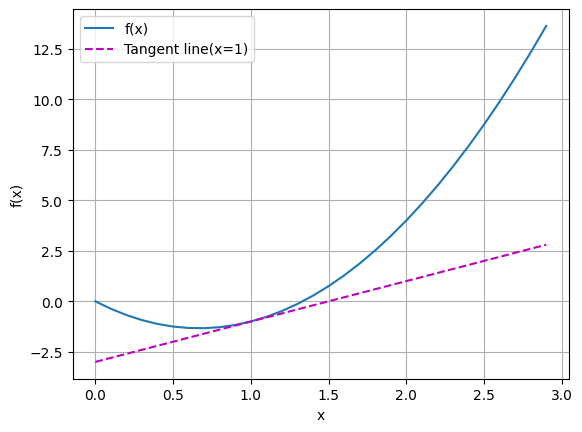

In [77]:
x=np.arange(0,3,0.1)
plot(x,[f(x),2*x-3],'x','f(x)',legend=['f(x)','Tangent line(x=1)'])


Font 'default' does not have a glyph for '\u5207' [U+5207], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u7ebf' [U+7ebf], substituting with a dummy symbol.
d:\miniconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
Font 'default' does not have a glyph for '\u5207' [U+5207], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u7ebf' [U+7ebf], substituting with a dummy symbol.


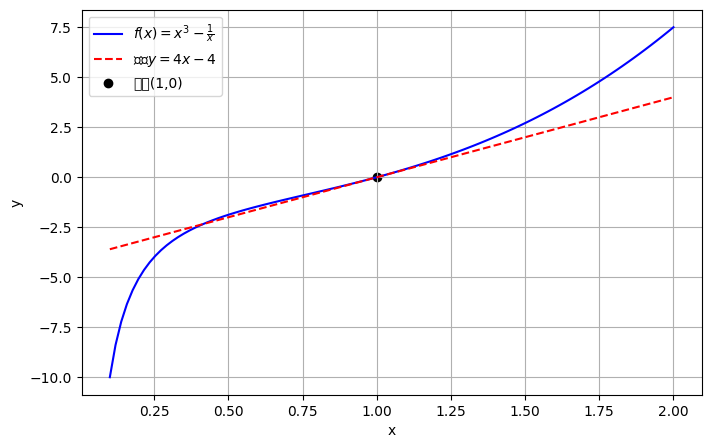

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# 定义函数和切线
def f(x):
    return x**3 - 1/x

def tangent(x):
    return 4*x - 4

# 定义域（避开x=0）
x = np.linspace(0.1, 2, 100)
y = f(x)
y_tan = tangent(x)

# 绘图
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$f(x)=x^3-\frac{1}{x}$', color='blue')
plt.plot(x, y_tan, label=r'切线$y=4x-4$', color='red', linestyle='--')
plt.scatter(1, 0, color='black', label='切点(1,0)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [79]:
import torch
x = torch.arange(5.0)
x

tensor([0., 1., 2., 3., 4.])

In [80]:
x.requires_grad_(True)
x.grad

In [81]:
y=3*x**3
y

tensor([  0.,   3.,  24.,  81., 192.], grad_fn=<MulBackward0>)

In [82]:
x.grad.zero_()  # 关键：清零梯度
y = 3 * x ** 3
y.sum().backward()
x.grad
# 输出: tensor([  0.,   9.,  36.,  81., 144.])  # 符合理论预期

AttributeError: 'NoneType' object has no attribute 'zero_'

In [ ]:
x.grad == 9*x**2

tensor([True, True, True, True, True])

In [ ]:
x.grad.zero_()
y=x.sum()
y.backward()   
x.grad

tensor([1., 1., 1., 1., 1.])

In [ ]:
x.grad.zero_()

tensor([0., 0., 0., 0., 0.])

In [ ]:
y=x**2
y.sum().backward()
x.grad

tensor([ 0.,  4.,  8., 12., 16.])

In [ ]:
x.grad.zero_()
y=x*x
u=y.detach()
z=u*x

z.sum().backward() 
x.grad==u
#求导完等于u，u是y的值，y=2*x，所以u=2*x，x.grad==u说明求导结果是2*x，符合理论预期

tensor([True, True, True, True, True])

In [ ]:
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True, True])

In [ ]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [ ]:
a= torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

In [ ]:
a.grad==d/a

tensor(True)

概率

In [ ]:
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

In [ ]:
fair_probs = torch.ones([6]) / 6
multinomial.Multinomial(1, fair_probs).sample()

tensor([0., 0., 0., 1., 0., 0.])

In [ ]:
multinomial.Multinomial(10, fair_probs).sample()

tensor([1., 1., 0., 2., 4., 2.])

In [ ]:
counts=multinomial.Multinomial(1000, fair_probs).sample()
counts/1000

tensor([0.1680, 0.1660, 0.1600, 0.1700, 0.1730, 0.1630])

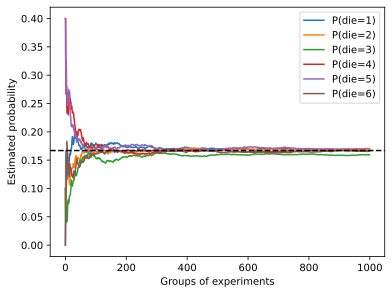

In [ ]:
counts = multinomial.Multinomial(10, fair_probs).sample((1000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

d2l.set_figsize((6, 4.5))
for i in range(6):
    d2l.plt.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Groups of experiments')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend();

In [84]:
import torch
print(dir(torch.distributions))

['AbsTransform', 'AffineTransform', 'Bernoulli', 'Beta', 'Binomial', 'CatTransform', 'Categorical', 'Cauchy', 'Chi2', 'ComposeTransform', 'ContinuousBernoulli', 'CorrCholeskyTransform', 'CumulativeDistributionTransform', 'Dirichlet', 'Distribution', 'ExpTransform', 'Exponential', 'ExponentialFamily', 'FisherSnedecor', 'Gamma', 'Geometric', 'Gumbel', 'HalfCauchy', 'HalfNormal', 'Independent', 'IndependentTransform', 'Kumaraswamy', 'LKJCholesky', 'Laplace', 'LogNormal', 'LogisticNormal', 'LowRankMultivariateNormal', 'LowerCholeskyTransform', 'MixtureSameFamily', 'Multinomial', 'MultivariateNormal', 'NegativeBinomial', 'Normal', 'OneHotCategorical', 'OneHotCategoricalStraightThrough', 'Pareto', 'Poisson', 'PowerTransform', 'RelaxedBernoulli', 'RelaxedOneHotCategorical', 'ReshapeTransform', 'SigmoidTransform', 'SoftmaxTransform', 'SoftplusTransform', 'StackTransform', 'StickBreakingTransform', 'StudentT', 'TanhTransform', 'Transform', 'TransformedDistribution', 'Uniform', 'VonMises', 'Weib

In [87]:
help(torch.ones)

Help on built-in function ones in module torch:

ones(...)
    ones(*size, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False) -> Tensor
    
    Returns a tensor filled with the scalar value `1`, with the shape defined
    by the variable argument :attr:`size`.
    
    Args:
        size (int...): a sequence of integers defining the shape of the output tensor.
            Can be a variable number of arguments or a collection like a list or tuple.
    
    Keyword arguments:
        out (Tensor, optional): the output tensor.
        dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
            Default: if ``None``, uses a global default (see :func:`torch.set_default_tensor_type`).
        layout (:class:`torch.layout`, optional): the desired layout of returned Tensor.
            Default: ``torch.strided``.
        device (:class:`torch.device`, optional): the desired device of returned tensor.
            Default: if ``None

In [88]:
##end